# 03 — Parameter Calibration & Unit Hygiene

> **Where this fits:** Notebook 02 characterized the empirical properties of funding rates
> across four venues — regime structure, persistence, tail heaviness, and cross-venue
> differences. This notebook uses those empirical facts to **freeze baseline parameters**
> for all DDX products. Every number computed here (deductible values, thresholds,
> activation rates) feeds directly into the premium surfaces (NB04) and all downstream
> pricing, frontier, and event-study work.

### What this notebook does

1. **Establishes unit conventions** — clearly separates per-interval rates (displayed as APR %)
   from per-window cumulative sums (displayed as % of notional per window).
2. **Computes conditional loss distributions** — quantiles of $l_i$ given $l_i > 0$, informing
   the Floor deductible $d$.
3. **Computes $\Lambda$ quantiles per horizon** — rolling aggregate loss distributions for 7d/30d/90d,
   informing the ASL deductible $D$.
4. **Analyzes DAF activation frequencies** — how often does the persistence gate trigger at
   different `(b, m)` combinations?
5. **Outputs a frozen parameter summary** — the baseline configuration for all subsequent phases.
6. **Tests cross-venue parameter portability** — do the same parameters produce similar behavior
   on other venues?

In [1]:
import os, sys
from pathlib import Path as _Path

import ddx as _ddx
REPO_ROOT = _Path(_ddx.__file__).resolve().parent.parent.parent
os.chdir(REPO_ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

from ddx.data.io import load_processed
from ddx.utils.units import (
    INTERVALS_PER_YEAR,
    to_apr_pct, to_pct_notional, to_ann_pct,
)
from ddx.calibration import (
    conditional_loss_quantiles,
    lambda_quantiles_per_horizon,
    daf_activation_analysis,
    compute_asl_deductible,
    freeze_baseline_parameters,
)
from ddx.utils.config import load_analysis_config

config = load_analysis_config()
horizons = config["horizons"]

venues = {
    "Bybit": load_processed(REPO_ROOT / "data/processed/bybit_btcusd.parquet"),
    "BitMEX": load_processed(REPO_ROOT / "data/processed/bitmex_xbtusd.parquet"),
    "Deribit": load_processed(REPO_ROOT / "data/processed/deribit_btcperp.parquet"),
    "Binance": load_processed(REPO_ROOT / "data/processed/binance_btcusd.parquet"),
}
primary_name = "Bybit"
df = venues[primary_name]
cf = df["funding_cf"].values
is_reg = df["is_regular"].values if "is_regular" in df.columns else None

for name, d in venues.items():
    n_irreg = int((~d["is_regular"]).sum()) if "is_regular" in d.columns else 0
    tag = " << PRIMARY" if name == primary_name else ""
    print(f"  {name}: {len(d):,} rows, {str(d['timestamp'].iloc[0])[:10]} to {str(d['timestamp'].iloc[-1])[:10]}, {n_irreg} irregular{tag}")

  Bybit: 7,971 rows, 2018-11-15 to 2026-02-23, 3 irregular << PRIMARY
  BitMEX: 10,675 rows, 2016-05-14 to 2026-02-23, 21 irregular
  Deribit: 7,474 rows, 2019-04-30 to 2026-02-23, 0 irregular
  Binance: 6,070 rows, 2020-08-10 to 2026-02-23, 0 irregular


## Section 1: Unit Convention Reference

Two fundamentally different quantities exist in this analysis:

| Quantity type | Examples | Display convention | Conversion |
|:---|:---|:---|:---|
| **Per-interval rate** | `f_i`, `l_i`, `d`, `b`, `k` | APR (%) | `rate × 1095 × 100` |
| **Per-window cumulative sum** | `Λ`, episode `total_loss`, payoff | % of notional per window | `sum × 100` |

**Critical rule:** Never apply `×1095` to a cumulative sum. A Lambda of 0.005 over a 30d window
means 0.5% of notional was lost to negative funding over those 30 days — *not* 547.5% APR.

If annualizing a window sum is needed (e.g., for comparability), divide by window length first:
`annualized = (sum / n_intervals) × 1095 × 100`.

## Section 2: Conditional Loss Distributions

The Floor deductible `d` should be chosen from the distribution of losses *given that a loss occurs*.
Using the unconditional distribution gives `p50(l_i) = 0` on Bybit because >80% of intervals
have non-negative funding — this is true but uninformative for product design.

In [2]:
quantile_levels = [0.25, 0.50, 0.75, 0.90, 0.95, 0.99]

print("=" * 80)
print("CONDITIONAL LOSS QUANTILES: l_i | l_i > 0")
print("=" * 80)

cond_rows = []
for vname, vdf in venues.items():
    vcf = vdf["funding_cf"].values
    cq = conditional_loss_quantiles(vcf, quantile_levels)
    row = {"Venue": vname, "N_negative": cq["n_negative"],
           "Frac_neg": f"{cq['frac_negative']:.1%}"}
    for q in quantile_levels:
        key = f"q{int(q*100):02d}"
        val = cq[key]
        row[f"p{int(q*100)} (per-8h)"] = f"{val:.6f}"
        row[f"p{int(q*100)} APR(%)"] = f"{to_apr_pct(val):.2f}%"
    cond_rows.append(row)

cond_df = pd.DataFrame(cond_rows)
display(cond_df)

print("\n--- Interpretation ---")
bybit_cq = conditional_loss_quantiles(cf, quantile_levels)
print(f"On Bybit, {bybit_cq['frac_negative']:.1%} of intervals produce a loss.")
print(f"Among those losing intervals:")
print(f"  Median loss (p50):  {bybit_cq['q50']:.6f} per 8h = {to_apr_pct(bybit_cq['q50']):.2f}% APR")
print(f"  p75 loss:           {bybit_cq['q75']:.6f} per 8h = {to_apr_pct(bybit_cq['q75']):.2f}% APR")
print(f"  p99 loss:           {bybit_cq['q99']:.6f} per 8h = {to_apr_pct(bybit_cq['q99']):.2f}% APR")
_lp = np.maximum(0.0, -cf); _lp = _lp[_lp > 0]
frac_below_0001 = np.sum(_lp <= 0.0001) / len(_lp)
frac_below_0003 = np.sum(_lp <= 0.0003) / len(_lp)
print(f"\nFloor deductible d=0.0001 ({to_apr_pct(0.0001):.1f}% APR) filters {frac_below_0001:.0%} of conditional losses.")
print(f"Floor deductible d=0.0003 ({to_apr_pct(0.0003):.1f}% APR) filters {frac_below_0003:.0%} of conditional losses.")

CONDITIONAL LOSS QUANTILES: l_i | l_i > 0


,Venue,N_negative,Frac_neg,p25 (per-8h),p25 APR(%),p50 (per-8h),p50 APR(%),p75 (per-8h),p75 APR(%),p90 (per-8h),p90 APR(%),p95 (per-8h),p95 APR(%),p99 (per-8h),p99 APR(%)
0,Bybit,1463,18.4%,0.000031,3.45%,0.000077,8.42%,0.000187,20.47%,0.000445,48.67%,0.000676,74.07%,0.001484,162.54%
1,BitMEX,2969,27.8%,0.000061,6.68%,0.000165,18.07%,0.000497,54.42%,0.001272,139.28%,0.001987,217.58%,0.003750,410.62%
2,Deribit,1978,26.5%,0.000001,0.14%,0.000008,0.91%,0.000041,4.54%,0.000131,14.37%,0.000256,28.00%,0.000981,107.44%
3,Binance,1075,17.7%,0.000022,2.41%,0.000051,5.56%,0.000100,10.99%,0.000163,17.85%,0.000230,25.13%,0.000508,55.67%



--- Interpretation ---
On Bybit, 18.4% of intervals produce a loss.
Among those losing intervals:
  Median loss (p50):  0.000077 per 8h = 8.42% APR
  p75 loss:           0.000187 per 8h = 20.47% APR
  p99 loss:           0.001484 per 8h = 162.54% APR

Floor deductible d=0.0001 (10.9% APR) filters 58% of conditional losses.
Floor deductible d=0.0003 (32.8% APR) filters 84% of conditional losses.


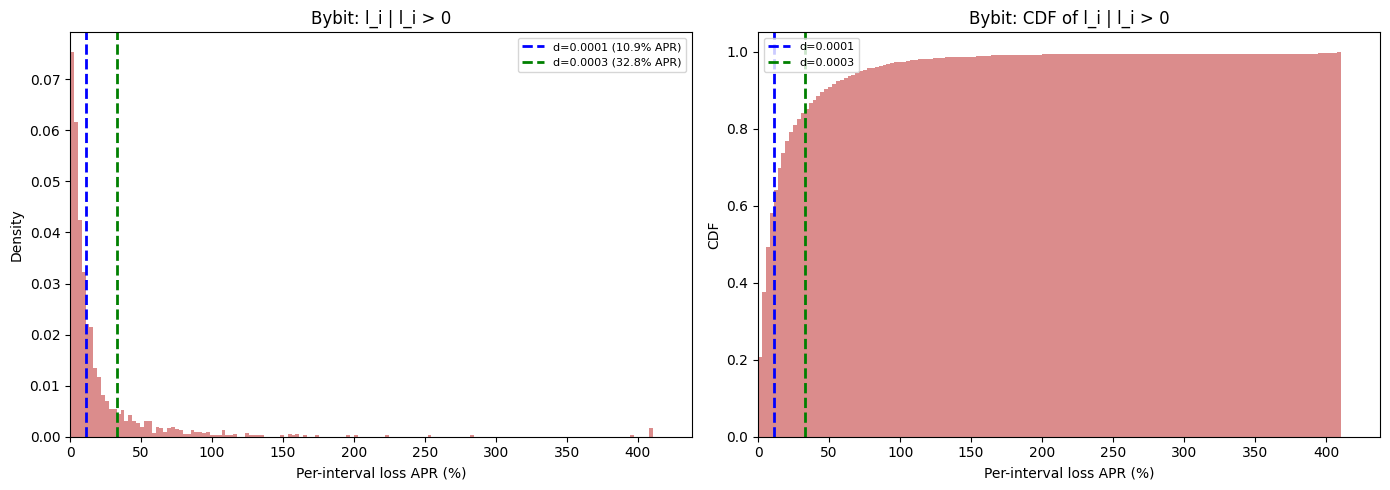

In [3]:
# Histogram of conditional losses with d markers
losses_pos = np.maximum(0.0, -cf)
losses_pos = losses_pos[losses_pos > 0]
losses_apr = to_apr_pct(losses_pos)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.hist(losses_apr, bins=150, density=True, alpha=0.7, color="indianred", edgecolor="none")
for d_val, color, label in [(0.0001, "blue", "d=0.0001"), (0.0003, "green", "d=0.0003")]:
    ax.axvline(to_apr_pct(d_val), color=color, linewidth=2, linestyle="--",
               label=f"{label} ({to_apr_pct(d_val):.1f}% APR)")
ax.set_xlabel("Per-interval loss APR (%)")
ax.set_ylabel("Density")
ax.set_title(f"{primary_name}: l_i | l_i > 0")
ax.legend(fontsize=8)
ax.set_xlim(0, to_apr_pct(0.004))

ax = axes[1]
ax.hist(losses_apr, bins=150, density=True, alpha=0.7, color="indianred",
        edgecolor="none", cumulative=True)
for d_val, color, label in [(0.0001, "blue", "d=0.0001"), (0.0003, "green", "d=0.0003")]:
    ax.axvline(to_apr_pct(d_val), color=color, linewidth=2, linestyle="--",
               label=f"{label}")
ax.set_xlabel("Per-interval loss APR (%)")
ax.set_ylabel("CDF")
ax.set_title(f"{primary_name}: CDF of l_i | l_i > 0")
ax.legend(fontsize=8)
ax.set_xlim(0, to_apr_pct(0.004))

fig.tight_layout()
fig.savefig("reports/figures/calibration_conditional_loss.png", dpi=150, bbox_inches="tight")
plt.show()

## Section 3: Lambda Quantiles Per Horizon

Lambda = sum(max(0, -f_i)) over a rolling window. This is the *aggregate reserve draw*
for the window. The ASL deductible D is set as a quantile of this distribution:

- **D = q90(Lambda)** → baseline (activates in ~10% of windows)
- **D = q95(Lambda)** → sensitivity / catastrophe layer (~5% activation)

In [4]:
lambda_qs = [0.50, 0.75, 0.80, 0.85, 0.90, 0.95, 0.99]

print("=" * 90)
print("LAMBDA QUANTILES PER HORIZON — Bybit")
print("=" * 90)

lambda_tables = {}
for h in horizons:
    hname, n_int = h["name"], h["intervals"]
    lq = lambda_quantiles_per_horizon(cf, is_reg, n_int, lambda_qs)
    lambda_tables[hname] = lq

    print(f"\n--- {hname} ({n_int} intervals, {lq['n_windows']} windows) ---")
    print(f"  Mean Lambda: {lq['mean_lambda']:.6f} ({to_pct_notional(lq['mean_lambda']):.4f}% of notional)")
    print(f"  Std Lambda:  {lq['std_lambda']:.6f} ({to_pct_notional(lq['std_lambda']):.4f}% of notional)")

    for q in lambda_qs:
        key = f"q{int(q*100):02d}"
        val = lq[key]
        pct = to_pct_notional(val)
        ann = to_ann_pct(val, n_int)
        print(f"  p{int(q*100):2d}: {val:.6f} = {pct:.4f}% of notional per {hname} (annualized: {ann:.2f}% APR)")

# Summary table
rows = []
for h in horizons:
    hname, n_int = h["name"], h["intervals"]
    lq = lambda_tables[hname]
    row = {"Horizon": hname, "Windows": lq["n_windows"],
           "Mean (% notional)": f"{to_pct_notional(lq['mean_lambda']):.4f}%"}
    for q in lambda_qs:
        key = f"q{int(q*100):02d}"
        row[f"p{int(q*100)} (% notional)"] = f"{to_pct_notional(lq[key]):.4f}%"
    rows.append(row)

display(pd.DataFrame(rows))

print("\n--- ASL Deductible D (frozen) ---")
for h in horizons:
    hname, n_int = h["name"], h["intervals"]
    D_base = lambda_tables[hname]["q90"]
    D_sens = lambda_tables[hname]["q95"]
    print(f"  {hname}: D_baseline (q90) = {D_base:.6f} ({to_pct_notional(D_base):.4f}% of notional)")
    print(f"  {hname}: D_sensitivity (q95) = {D_sens:.6f} ({to_pct_notional(D_sens):.4f}% of notional)")

LAMBDA QUANTILES PER HORIZON — Bybit

--- 7d (21 intervals, 7888 windows) ---
  Mean Lambda: 0.000686 (0.0686% of notional)
  Std Lambda:  0.001927 (0.1927% of notional)
  p50: 0.000102 = 0.0102% of notional per 7d (annualized: 0.53% APR)
  p75: 0.000548 = 0.0548% of notional per 7d (annualized: 2.86% APR)
  p80: 0.000739 = 0.0739% of notional per 7d (annualized: 3.85% APR)
  p85: 0.001083 = 0.1083% of notional per 7d (annualized: 5.64% APR)
  p90: 0.001701 = 0.1701% of notional per 7d (annualized: 8.87% APR)
  p95: 0.003153 = 0.3153% of notional per 7d (annualized: 16.44% APR)
  p99: 0.009176 = 0.9176% of notional per 7d (annualized: 47.85% APR)



--- 30d (90 intervals, 7634 windows) ---
  Mean Lambda: 0.002731 (0.2731% of notional)
  Std Lambda:  0.005239 (0.5239% of notional)
  p50: 0.000773 = 0.0773% of notional per 30d (annualized: 0.94% APR)
  p75: 0.002583 = 0.2583% of notional per 30d (annualized: 3.14% APR)
  p80: 0.003177 = 0.3177% of notional per 30d (annualized: 3.86% APR)
  p85: 0.005657 = 0.5657% of notional per 30d (annualized: 6.88% APR)
  p90: 0.008114 = 0.8114% of notional per 30d (annualized: 9.87% APR)
  p95: 0.012967 = 1.2967% of notional per 30d (annualized: 15.78% APR)
  p99: 0.028749 = 2.8749% of notional per 30d (annualized: 34.98% APR)

--- 90d (270 intervals, 7194 windows) ---
  Mean Lambda: 0.007560 (0.7560% of notional)
  Std Lambda:  0.010558 (1.0558% of notional)
  p50: 0.002752 = 0.2752% of notional per 90d (annualized: 1.12% APR)
  p75: 0.008977 = 0.8977% of notional per 90d (annualized: 3.64% APR)
  p80: 0.010031 = 1.0031% of notional per 90d (annualized: 4.07% APR)
  p85: 0.016416 = 1.6416% of 

,Horizon,Windows,Mean (% notional),p50 (% notional),p75 (% notional),p80 (% notional),p85 (% notional),p90 (% notional),p95 (% notional),p99 (% notional)
0,7d,7888,0.0686%,0.0102%,0.0548%,0.0739%,0.1083%,0.1701%,0.3153%,0.9176%
1,30d,7634,0.2731%,0.0773%,0.2583%,0.3177%,0.5657%,0.8114%,1.2967%,2.8749%
2,90d,7194,0.7560%,0.2752%,0.8977%,1.0031%,1.6416%,2.3236%,2.9158%,5.2326%



--- ASL Deductible D (frozen) ---
  7d: D_baseline (q90) = 0.001701 (0.1701% of notional)
  7d: D_sensitivity (q95) = 0.003153 (0.3153% of notional)
  30d: D_baseline (q90) = 0.008114 (0.8114% of notional)
  30d: D_sensitivity (q95) = 0.012967 (1.2967% of notional)
  90d: D_baseline (q90) = 0.023236 (2.3236% of notional)
  90d: D_sensitivity (q95) = 0.029158 (2.9158% of notional)


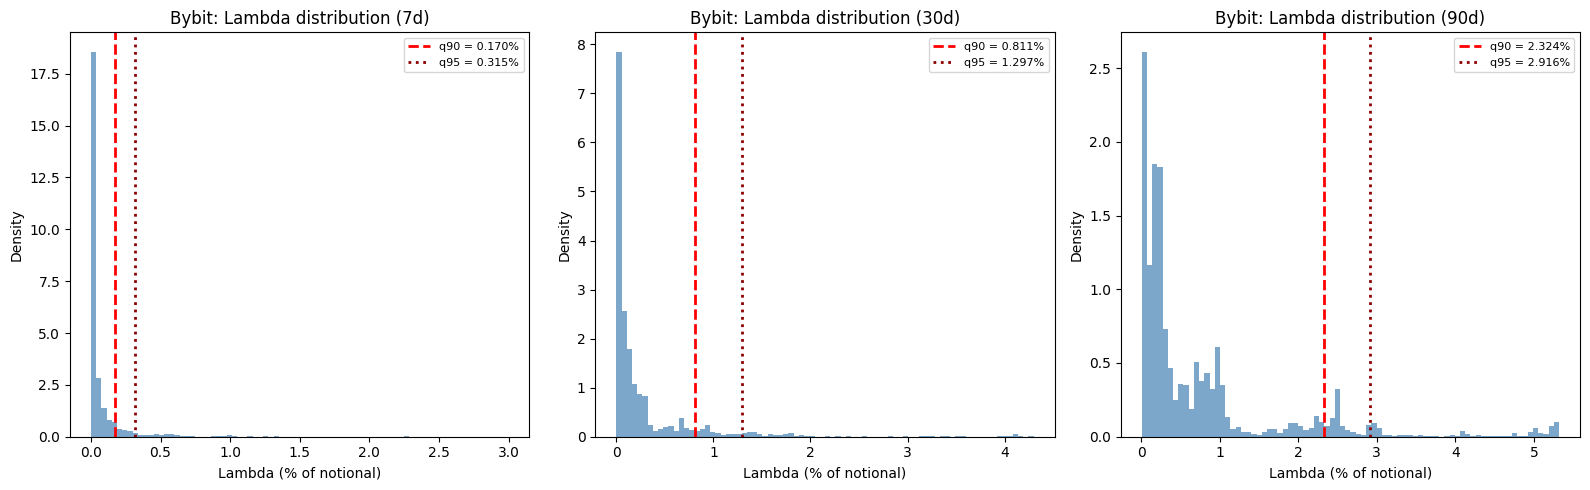

In [5]:
# Lambda distribution plots per horizon
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx, h in enumerate(horizons):
    hname, n_int = h["name"], h["intervals"]
    lq = lambda_tables[hname]

    if is_reg is not None:
        from ddx.backtest.rolling import rolling_windows_regular
        wins, _ = rolling_windows_regular(cf, is_reg, n_int)
    else:
        from ddx.backtest.rolling import rolling_windows
        wins = rolling_windows(cf, n_int)

    from ddx.risk.metrics import total_loss
    lambdas = np.array([total_loss(w) for w in wins])
    lambdas_pct = to_pct_notional(lambdas)

    ax = axes[idx]
    ax.hist(lambdas_pct, bins=80, density=True, alpha=0.7, color="steelblue", edgecolor="none")

    D90 = to_pct_notional(lq["q90"])
    D95 = to_pct_notional(lq["q95"])
    ax.axvline(D90, color="red", linewidth=2, linestyle="--",
               label=f"q90 = {D90:.3f}%")
    ax.axvline(D95, color="darkred", linewidth=2, linestyle=":",
               label=f"q95 = {D95:.3f}%")

    ax.set_xlabel("Lambda (% of notional)")
    ax.set_ylabel("Density")
    ax.set_title(f"{primary_name}: Lambda distribution ({hname})")
    ax.legend(fontsize=8)

fig.tight_layout()
fig.savefig("reports/figures/calibration_lambda_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

## Section 4: DAF Activation Analysis

The Distress-Activated Floor pays only after `m` consecutive intervals where `f_i < -b`.
Setting `d = b` makes the threshold an actual strike: payoff = max(0, -f_i - b) per active interval.

Key question: how often does the DAF actually activate?

In [6]:
print("=" * 90)
print("DAF ACTIVATION ANALYSIS — Bybit")
print("=" * 90)

b_values = [0.0, 0.0001, 0.0003]
m_values = [2, 3, 4, 5]

daf_rows = []
for h in horizons:
    hname, n_int = h["name"], h["intervals"]
    print(f"\n--- {hname} ---")

    for b in b_values:
        for m in m_values:
            res = daf_activation_analysis(cf, is_reg, n_int, b, m)
            daf_rows.append({
                "Horizon": hname,
                "b": b,
                "b APR(%)": f"{to_apr_pct(b):.1f}%",
                "m": m,
                "% windows activated": f"{res['frac_windows_activated']:.1%}",
                "Mean active intervals": f"{res['mean_activated_intervals']:.2f}",
                "Mean payoff (% notional)": f"{to_pct_notional(res['mean_payoff']):.4f}%",
                "Mean payoff|active (% notional)": (
                    f"{to_pct_notional(res['mean_payoff_when_active']):.4f}%"
                    if res['mean_payoff_when_active'] > 0 else "—"
                ),
            })

daf_df = pd.DataFrame(daf_rows)
display(daf_df)

# Highlight baseline (b=0.0001, m=3) vs sensitivity (b=0.0001, m=2) for 30d
print("\n--- Baseline vs Sensitivity (30d horizon) ---")
base_30 = daf_activation_analysis(cf, is_reg, 90, 0.0001, 3)
sens_30 = daf_activation_analysis(cf, is_reg, 90, 0.0001, 2)
print(f"  DAF m=3 (baseline):    {base_30['frac_windows_activated']:.1%} of 30d windows activate")
print(f"    Mean payoff: {to_pct_notional(base_30['mean_payoff']):.4f}% of notional")
print(f"  DAF m=2 (sensitivity): {sens_30['frac_windows_activated']:.1%} of 30d windows activate")
print(f"    Mean payoff: {to_pct_notional(sens_30['mean_payoff']):.4f}% of notional")

DAF ACTIVATION ANALYSIS — Bybit

--- 7d ---



--- 30d ---



--- 90d ---


,Horizon,b,b APR(%),m,% windows activated,Mean active intervals,Mean payoff (% notional),Mean payoff|active (% notional)
0,7d,0.0000,0.0%,2,42.9%,1.82,0.0413%,0.0962%
1,7d,0.0000,0.0%,3,26.5%,1.02,0.0283%,0.1071%
2,7d,0.0000,0.0%,4,16.5%,0.65,0.0213%,0.1291%
3,7d,0.0000,0.0%,5,11.1%,0.46,0.0164%,0.1483%
4,7d,0.0001,10.9%,2,19.4%,0.67,0.0239%,0.1230%
5,7d,0.0001,10.9%,3,9.9%,0.38,0.0167%,0.1691%
6,7d,0.0001,10.9%,4,6.2%,0.24,0.0124%,0.2012%
7,7d,0.0001,10.9%,5,4.5%,0.17,0.0089%,0.1991%
8,7d,0.0003,32.8%,2,7.1%,0.25,0.0121%,0.1698%
9,7d,0.0003,32.8%,3,2.8%,0.14,0.0081%,0.2922%



--- Baseline vs Sensitivity (30d horizon) ---


  DAF m=3 (baseline):    24.5% of 30d windows activate
    Mean payoff: 0.0695% of notional
  DAF m=2 (sensitivity): 45.1% of 30d windows activate
    Mean payoff: 0.0959% of notional


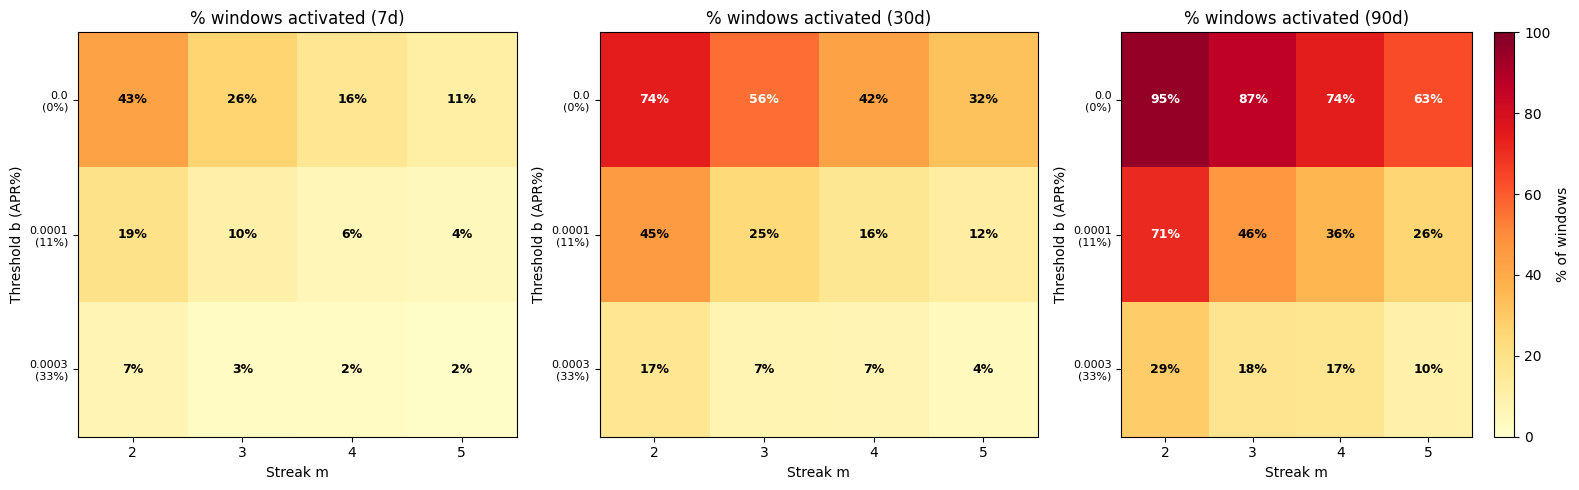

In [7]:
# Activation frequency heatmap for 30d horizon
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx, h in enumerate(horizons):
    hname, n_int = h["name"], h["intervals"]
    act_matrix = np.zeros((len(b_values), len(m_values)))

    for i, b in enumerate(b_values):
        for j, m in enumerate(m_values):
            res = daf_activation_analysis(cf, is_reg, n_int, b, m)
            act_matrix[i, j] = res["frac_windows_activated"] * 100

    ax = axes[idx]
    im = ax.imshow(act_matrix, aspect="auto", cmap="YlOrRd", vmin=0, vmax=100)
    ax.set_xticks(range(len(m_values)))
    ax.set_xticklabels([str(m) for m in m_values])
    ax.set_yticks(range(len(b_values)))
    ax.set_yticklabels([f"{b}\n({to_apr_pct(b):.0f}%)" for b in b_values], fontsize=8)
    ax.set_xlabel("Streak m")
    ax.set_ylabel("Threshold b (APR%)")
    ax.set_title(f"% windows activated ({hname})")

    for i in range(len(b_values)):
        for j in range(len(m_values)):
            val = act_matrix[i, j]
            color = "white" if val > 50 else "black"
            ax.text(j, i, f"{val:.0f}%", ha="center", va="center",
                    fontsize=9, color=color, fontweight="bold")

fig.colorbar(im, ax=axes[-1], label="% of windows")
fig.tight_layout()
fig.savefig("reports/figures/calibration_daf_activation.png", dpi=150, bbox_inches="tight")
plt.show()

## Section 5: Frozen Parameter Summary

These are the baseline parameters for all downstream analysis (Phases 6–8).

**Static reference (readable without execution):**

| Product | Parameter | Value | Display | Rationale |
|---------|-----------|-------|---------|----------|
| Floor benchmark | d | 0 | 0% APR | Full insurance upper bound |
| Floor realistic | d | 0.0001 | 10.95% APR | Severity strike at 1 bp; filters ~58% of conditional losses |
| Floor realistic alt | d | 0.0003 | 32.85% APR | Higher severity strike; filters ~84% |
| DAF baseline | b=d=0.0001, m=3 | — | 10.95% APR, 24h | Noise-robust persistence gate; strike continuity |
| DAF sensitivity | b=d=0.0001, m=2 | — | 10.95% APR, 16h | More sensitive trigger |
| ASL baseline (7d) | D=q90 | 0.001701 | 0.170% notional | ~10% activation, reinsurance layer |
| ASL baseline (30d) | D=q90 | 0.008114 | 0.811% notional | ~10% activation |
| ASL baseline (90d) | D=q90 | 0.023236 | 2.324% notional | ~10% activation |
| Swap primary | EWMA mean | lookback=90, halflife=45 | — | Market-adaptive |
| Swap secondary | Trailing mean | lookback=90 | — | Robustness check |

The code below computes these values from data and confirms them.

In [8]:
params = freeze_baseline_parameters(cf, is_reg, horizons, config)

print("=" * 90)
print("FROZEN BASELINE PARAMETERS")
print("=" * 90)

print("\n--- Floor ---")
print(f"  Benchmark:      d = 0       (full insurance upper bound)")
print(f"  Realistic:      d = 0.0001  ({to_apr_pct(0.0001):.1f}% APR — filters ~58% of conditional losses)")
print(f"  Realistic alt:  d = 0.0003  ({to_apr_pct(0.0003):.1f}% APR — filters ~84% of conditional losses)")

print("\n--- DAF (d = b for strike continuity) ---")
daf_b = params["daf"]["baseline"]
daf_s = params["daf"]["sensitivity"]
print(f"  Baseline:    b={daf_b['threshold_b']}, m={daf_b['streak_m']}, d=b={daf_b['deductible_d']}")
print(f"               ({to_apr_pct(daf_b['threshold_b']):.1f}% APR threshold, 24h sustained distress)")
print(f"  Sensitivity: b={daf_s['threshold_b']}, m={daf_s['streak_m']}, d=b={daf_s['deductible_d']}")
print(f"               ({to_apr_pct(daf_s['threshold_b']):.1f}% APR threshold, 16h trigger)")

print("\n--- ASL (D per horizon, from Lambda quantiles) ---")
for h in horizons:
    hname = h["name"]
    hp = params["horizons"][hname]
    D_base = hp["asl"]["baseline"]["deductible_D"]
    D_sens = hp["asl"]["sensitivity"]["deductible_D"]
    print(f"  {hname} baseline (q90):     D = {D_base:.6f} ({to_pct_notional(D_base):.4f}% of notional)")
    print(f"  {hname} sensitivity (q95):  D = {D_sens:.6f} ({to_pct_notional(D_sens):.4f}% of notional)")

print("\n--- Swap ---")
sw = params["swap"]
print(f"  Primary:   {sw['primary']['method']} (lookback={sw['primary']['lookback']} intervals, halflife={sw['primary']['halflife']})")
print(f"  Secondary: {sw['secondary']['method']} (lookback={sw['secondary']['lookback']} intervals)")

print("\n--- DAF Activation Rates (30d) ---")
hp30 = params["horizons"]["30d"]
act_base = hp30["daf_activation"]["baseline_m3"]
act_sens = hp30["daf_activation"]["sensitivity_m2"]
print(f"  m=3 baseline:    {act_base['frac_windows_activated']:.1%} of windows activate")
print(f"  m=2 sensitivity: {act_sens['frac_windows_activated']:.1%} of windows activate")

FROZEN BASELINE PARAMETERS

--- Floor ---
  Benchmark:      d = 0       (full insurance upper bound)
  Realistic:      d = 0.0001  (10.9% APR — filters ~58% of conditional losses)
  Realistic alt:  d = 0.0003  (32.8% APR — filters ~84% of conditional losses)

--- DAF (d = b for strike continuity) ---
  Baseline:    b=0.0001, m=3, d=b=0.0001
               (10.9% APR threshold, 24h sustained distress)
  Sensitivity: b=0.0001, m=2, d=b=0.0001
               (10.9% APR threshold, 16h trigger)

--- ASL (D per horizon, from Lambda quantiles) ---
  7d baseline (q90):     D = 0.001701 (0.1701% of notional)
  7d sensitivity (q95):  D = 0.003153 (0.3153% of notional)
  30d baseline (q90):     D = 0.008114 (0.8114% of notional)
  30d sensitivity (q95):  D = 0.012967 (1.2967% of notional)
  90d baseline (q90):     D = 0.023236 (2.3236% of notional)
  90d sensitivity (q95):  D = 0.029158 (2.9158% of notional)

--- Swap ---
  Primary:   ewma (lookback=90 intervals, halflife=45)
  Secondary: mean (l

In [9]:
# Save the frozen parameter summary as a structured table
summary_rows = [
    {"Product": "Floor benchmark", "Parameter": "d=0, cap=None",
     "Value": "d=0.0", "APR/Notional": "0% APR deductible",
     "Rationale": "Full insurance upper bound"},
    {"Product": "Floor realistic", "Parameter": "d=0.0001, cap=None",
     "Value": "d=0.0001", "APR/Notional": f"{to_apr_pct(0.0001):.1f}% APR",
     "Rationale": "Severity strike at 1 bp (exchange natural scale); filters ~58% of conditional losses"},
    {"Product": "DAF baseline", "Parameter": "b=0.0001, m=3, d=b",
     "Value": "b=d=0.0001, m=3",
     "APR/Notional": f"{to_apr_pct(0.0001):.1f}% APR threshold",
     "Rationale": "24h sustained distress; noise-robust persistence gate; strike continuity"},
    {"Product": "DAF sensitivity", "Parameter": "b=0.0001, m=2, d=b",
     "Value": "b=d=0.0001, m=2",
     "APR/Notional": f"{to_apr_pct(0.0001):.1f}% APR threshold",
     "Rationale": "16h trigger, more sensitive"},
]

for h in horizons:
    hname = h["name"]
    hp = params["horizons"][hname]
    D_base = hp["asl"]["baseline"]["deductible_D"]
    D_sens = hp["asl"]["sensitivity"]["deductible_D"]
    summary_rows.append({
        "Product": f"ASL baseline ({hname})",
        "Parameter": "D=q90(Lambda)",
        "Value": f"D={D_base:.6f}",
        "APR/Notional": f"{to_pct_notional(D_base):.4f}% of notional",
        "Rationale": f"~10% activation, tail reinsurance",
    })
    summary_rows.append({
        "Product": f"ASL sensitivity ({hname})",
        "Parameter": "D=q95(Lambda)",
        "Value": f"D={D_sens:.6f}",
        "APR/Notional": f"{to_pct_notional(D_sens):.4f}% of notional",
        "Rationale": f"~5% activation, catastrophe layer",
    })

summary_rows.append({
    "Product": "Swap primary", "Parameter": "EWMA mean",
    "Value": "lookback=90, halflife=45",
    "APR/Notional": "—",
    "Rationale": "Market-adaptive, recency-weighted",
})
summary_rows.append({
    "Product": "Swap secondary", "Parameter": "Trailing mean",
    "Value": "lookback=90",
    "APR/Notional": "—",
    "Rationale": "Simple benchmark for robustness",
})

summary_df = pd.DataFrame(summary_rows)
display(summary_df)
summary_df.to_csv("reports/tables/frozen_baseline_parameters.csv", index=False)
print("\nSaved: reports/tables/frozen_baseline_parameters.csv")

,Product,Parameter,Value,APR/Notional,Rationale
0,Floor benchmark,"d=0, cap=None",d=0.0,0% APR deductible,Full insurance upper bound
1,Floor realistic,"d=0.0001, cap=None",d=0.0001,10.9% APR,Severity strike at 1 bp (exchange natural scal...
2,DAF baseline,"b=0.0001, m=3, d=b","b=d=0.0001, m=3",10.9% APR threshold,24h sustained distress; noise-robust persisten...
3,DAF sensitivity,"b=0.0001, m=2, d=b","b=d=0.0001, m=2",10.9% APR threshold,"16h trigger, more sensitive"
4,ASL baseline (7d),D=q90(Lambda),D=0.001701,0.1701% of notional,"~10% activation, tail reinsurance"
5,ASL sensitivity (7d),D=q95(Lambda),D=0.003153,0.3153% of notional,"~5% activation, catastrophe layer"
6,ASL baseline (30d),D=q90(Lambda),D=0.008114,0.8114% of notional,"~10% activation, tail reinsurance"
7,ASL sensitivity (30d),D=q95(Lambda),D=0.012967,1.2967% of notional,"~5% activation, catastrophe layer"
8,ASL baseline (90d),D=q90(Lambda),D=0.023236,2.3236% of notional,"~10% activation, tail reinsurance"
9,ASL sensitivity (90d),D=q95(Lambda),D=0.029158,2.9158% of notional,"~5% activation, catastrophe layer"



Saved: reports/tables/frozen_baseline_parameters.csv


## Section 6: Cross-Venue Parameter Portability

Do the Bybit-calibrated parameters produce similar activation frequencies on other venues?
Deribit is expected to differ (no base rate, no hard cap).

In [10]:
print("=" * 90)
print("CROSS-VENUE PARAMETER PORTABILITY — DAF b=0.0001, m=3, 30d horizon")
print("=" * 90)

xv_rows = []
for vname, vdf in venues.items():
    vcf = vdf["funding_cf"].values
    vis_reg = vdf["is_regular"].values if "is_regular" in vdf.columns else None

    daf_res = daf_activation_analysis(vcf, vis_reg, 90, 0.0001, 3)
    lq = lambda_quantiles_per_horizon(vcf, vis_reg, 90, [0.90, 0.95])

    cq = conditional_loss_quantiles(vcf, [0.50, 0.75])

    xv_rows.append({
        "Venue": vname,
        "DAF activation (30d)": f"{daf_res['frac_windows_activated']:.1%}",
        "Mean payoff (% not.)": f"{to_pct_notional(daf_res['mean_payoff']):.4f}%",
        "Lambda q90 (% not.)": f"{to_pct_notional(lq['q90']):.4f}%",
        "Lambda q95 (% not.)": f"{to_pct_notional(lq['q95']):.4f}%",
        "Cond l_i p50 (per-8h)": f"{cq['q50']:.6f}",
        "Cond l_i p75 (per-8h)": f"{cq['q75']:.6f}",
    })

xv_df = pd.DataFrame(xv_rows)
display(xv_df)
xv_df.to_csv("reports/tables/cross_venue_portability.csv", index=False)

print("\n--- Observations ---")
print("Deribit is expected to differ significantly due to:")
print("  - No discrete base rate at 0.0001")
print("  - No hard cap on per-interval funding")
print("  - Left-skewed distribution (structurally different microstructure)")
print("\nDeribit will need venue-specific calibration in Phase 9.")

CROSS-VENUE PARAMETER PORTABILITY — DAF b=0.0001, m=3, 30d horizon


,Venue,DAF activation (30d),Mean payoff (% not.),Lambda q90 (% not.),Lambda q95 (% not.),Cond l_i p50 (per-8h),Cond l_i p75 (per-8h)
0,Bybit,24.5%,0.0695%,0.8114%,1.2967%,0.000077,0.000187
1,BitMEX,54.3%,0.5548%,4.1811%,5.5433%,0.000165,0.000497
2,Deribit,14.8%,0.0549%,0.3884%,0.5934%,0.000008,0.000041
3,Binance,18.9%,0.0091%,0.3311%,0.5319%,0.000051,0.000100



--- Observations ---
Deribit is expected to differ significantly due to:
  - No discrete base rate at 0.0001
  - No hard cap on per-interval funding
  - Left-skewed distribution (structurally different microstructure)

Deribit will need venue-specific calibration in Phase 9.


## Key Findings

1. **Unit hygiene is now enforced**: per-interval rates use APR (%), cumulative sums use % of notional.

2. **Floor deductible d=0.0001** filters ~58% of conditional loss intervals (those below 1 bp per 8h
   in magnitude). d=0.0003 is a more aggressive filter that excludes ~84% of loss intervals.

3. **ASL deductible D=q90(Lambda)** creates a reinsurance-style tail layer that activates in
   approximately 10% of rolling windows — much more appropriate than q75 (which activates ~25%).

4. **DAF with m=3 (24h sustained distress)** activates in a meaningful but not excessive fraction
   of windows. Combined with d=b, this creates a clean "strike + persistence gate" product.

5. **Cross-venue portability**: Parameters calibrated on Bybit produce broadly similar behavior
   on BitMEX and Binance, but Deribit requires separate calibration due to its structurally
   different funding mechanism.

6. **SDC is pruned from mainline analysis** — synthetic results showed it has the lowest sharpness.
   It remains available in appendix configs for mechanism-design discussions.

---

### What these results mean for the next notebooks

The frozen parameters from this notebook are the foundation for all pricing:

| Product | Frozen params | Used in |
|---------|--------------|---------|
| Floor realistic | d=0.0001 | NB04 premium sweep, NB06 frontiers |
| DAF baseline | b=0.0001, m=3, d=b | NB04 premium sweep, NB06 frontiers |
| ASL baseline | $D = q_{90}(\Lambda)$ per horizon | NB04 premium sweep, NB06 frontiers |

**Next → Notebook 04** computes the actual cost of each product (premium surfaces) across
the full deductible/parameter grids, decomposes premiums into pure/risk-load/capital-charge,
and adds bootstrap confidence intervals to quantify how uncertain those prices are.